# Dataset

In [1]:
!pip install torch-geometric -q

import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_undirected
from torch_geometric.transforms import NormalizeFeatures

dataset = Planetoid(
    root='/kaggle/working/Cora',
    name='Cora',
    transform=NormalizeFeatures()
)

data = dataset[0]

print("Nodes:", data.num_nodes)
print("Edges:", data.num_edges)
print("Features per node:", dataset.num_node_features)
print("Classes:", dataset.num_classes)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.1 MB/s eta 0:00:00:00:01


Processing...


Nodes: 2708
Edges: 10556
Features per node: 1433
Classes: 7


Done!


In [5]:
# Class distribution
import collections

labels = data.y.numpy()
label_counts = collections.Counter(labels)

print("Class distribution:")
for cls in sorted(label_counts):
    print(f"  Class {cls}: {label_counts[cls]} nodes")

print(f"\nTrain: {data.train_mask.sum().item()}")
print(f"Val:   {data.val_mask.sum().item()}")
print(f"Test:  {data.test_mask.sum().item()}")

Class distribution:
  Class 0: 351 nodes
  Class 1: 217 nodes
  Class 2: 418 nodes
  Class 3: 818 nodes
  Class 4: 426 nodes
  Class 5: 298 nodes
  Class 6: 180 nodes

Train: 140
Val:   500
Test:  1000


In [6]:
# Feature matrix
print("Feature matrix shape:", data.x.shape)
print("Feature dtype:", data.x.dtype)
print("Sparse? Non-zero features per node (avg):", (data.x > 0).sum(dim=1).float().mean().item())
print("Min non-zero per node:", (data.x > 0).sum(dim=1).min().item())
print("Max non-zero per node:", (data.x > 0).sum(dim=1).max().item())

Feature matrix shape: torch.Size([2708, 1433])
Feature dtype: torch.float32
Sparse? Non-zero features per node (avg): 18.174299240112305
Min non-zero per node: 1
Max non-zero per node: 30


In [7]:
# Edge index and degree distribution
import numpy as np

edge_index = to_undirected(data.edge_index)
degrees = torch.zeros(data.num_nodes, dtype=torch.long)
degrees.scatter_add_(0, edge_index[0], torch.ones(edge_index.size(1), dtype=torch.long))

print("Degree stats:")
print(f"  Min: {degrees.min().item()}")
print(f"  Max: {degrees.max().item()}")
print(f"  Mean: {degrees.float().mean().item():.2f}")
print(f"  Median: {degrees.float().median().item():.1f}")
print(f"  Isolated nodes (deg=0): {(degrees == 0).sum().item()}")

Degree stats:
  Min: 1
  Max: 168
  Mean: 3.90
  Median: 3.0
  Isolated nodes (deg=0): 0


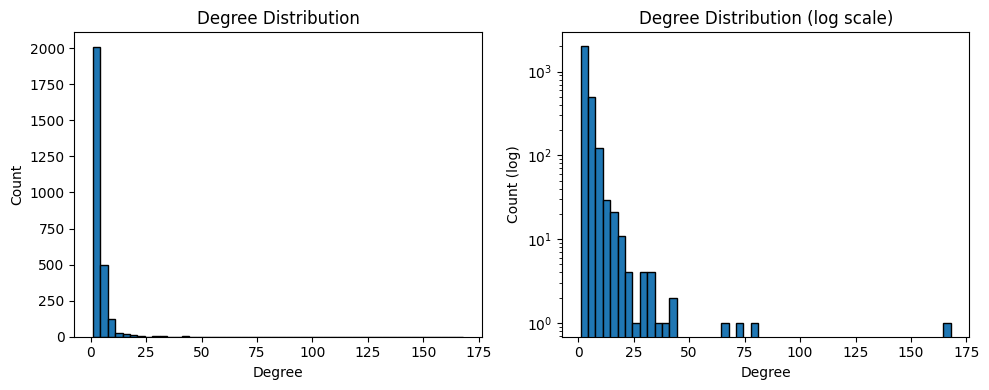

In [8]:
# Degree distribution plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(degrees.numpy(), bins=50, edgecolor='black')
plt.xlabel('Degree')
plt.ylabel('Count')
plt.title('Degree Distribution')

plt.subplot(1, 2, 2)
plt.hist(degrees.numpy(), bins=50, edgecolor='black', log=True)
plt.xlabel('Degree')
plt.ylabel('Count (log)')
plt.title('Degree Distribution (log scale)')

plt.tight_layout()
plt.show()

In [9]:
# Graph structure
import networkx as nx

G_nx = nx.Graph()
G_nx.add_nodes_from(range(data.num_nodes))
G_nx.add_edges_from(edge_index.t().cpu().numpy().tolist())

print("Connected:", nx.is_connected(G_nx))
print("Components:", nx.number_connected_components(G_nx))

components = sorted(nx.connected_components(G_nx), key=len, reverse=True)
for i, c in enumerate(components):
    print(f"  Component {i}: {len(c)} nodes")

Connected: False
Components: 78
  Component 0: 2485 nodes
  Component 1: 26 nodes
  Component 2: 9 nodes
  Component 3: 8 nodes
  Component 4: 6 nodes
  Component 5: 5 nodes
  Component 6: 5 nodes
  Component 7: 5 nodes
  Component 8: 4 nodes
  Component 9: 4 nodes
  Component 10: 4 nodes
  Component 11: 4 nodes
  Component 12: 4 nodes
  Component 13: 4 nodes
  Component 14: 3 nodes
  Component 15: 3 nodes
  Component 16: 3 nodes
  Component 17: 3 nodes
  Component 18: 3 nodes
  Component 19: 3 nodes
  Component 20: 3 nodes
  Component 21: 2 nodes
  Component 22: 2 nodes
  Component 23: 2 nodes
  Component 24: 2 nodes
  Component 25: 2 nodes
  Component 26: 2 nodes
  Component 27: 2 nodes
  Component 28: 2 nodes
  Component 29: 2 nodes
  Component 30: 2 nodes
  Component 31: 2 nodes
  Component 32: 2 nodes
  Component 33: 2 nodes
  Component 34: 2 nodes
  Component 35: 2 nodes
  Component 36: 2 nodes
  Component 37: 2 nodes
  Component 38: 2 nodes
  Component 39: 2 nodes
  Component 40

In [10]:
# Homophily — how often do connected nodes share the same label?
src, dst = edge_index
same_label = (data.y[src] == data.y[dst]).float().mean().item()
print(f"Edge homophily: {same_label:.4f}")
print("(1.0 = all edges connect same-class nodes, 0.0 = none do)")

Edge homophily: 0.8100
(1.0 = all edges connect same-class nodes, 0.0 = none do)


# Working Model

In [1]:
# =========================
# STEP 1: Install & Imports
# =========================

!pip install torch-geometric -q

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_undirected
from torch_geometric.transforms import NormalizeFeatures

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# Load Cora
# =========================

dataset = Planetoid(
    root='/kaggle/working/Cora',
    name='Cora',
    transform=NormalizeFeatures()
)

data = dataset[0].to(device)

print("Number of nodes:", data.num_nodes)
print("Number of edges:", data.num_edges)
print("Number of features:", dataset.num_node_features)
print("Number of classes:", dataset.num_classes)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 15.1 MB/s eta 0:00:0000:0100:01
Using device: cpu


Processing...


Number of nodes: 2708
Number of edges: 10556
Number of features: 1433
Number of classes: 7


Done!


In [25]:
# =====================================
# STEP 2: Define HGNN Layer and Model
# =====================================

class HGNNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(HGNNLayer, self).__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x, G):
        x = self.linear(x)
        x = torch.sparse.mm(G, x)
        return x


class HGNN(nn.Module):
    def __init__(self, in_features, hidden_dim, num_classes, dropout=0.5):
        super(HGNN, self).__init__()

        self.h1 = HGNNLayer(in_features, hidden_dim)
        self.h2 = HGNNLayer(hidden_dim, num_classes)
        self.dropout = dropout

    def forward(self, x, G):
        x = self.h1(x, G)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.h2(x, G)
        return x

In [26]:
import networkx as nx

edge_index = to_undirected(data.edge_index)
G_nx = nx.Graph()
G_nx.add_nodes_from(range(data.num_nodes))
G_nx.add_edges_from(edge_index.t().cpu().numpy().tolist())

# Extract connected components sorted by size
components = sorted(nx.connected_components(G_nx), key=len, reverse=True)
print(f"Total components: {len(components)}")
for i, c in enumerate(components):
    print(f"  Component {i}: {len(c)} nodes")

# Use only the largest component for DOSAGE
G_main = G_nx.subgraph(components[0]).copy()
print(f"\nRunning DOSAGE on component 0: {G_main.number_of_nodes()} nodes, {G_main.number_of_edges()} edges")

Total components: 78
  Component 0: 2485 nodes
  Component 1: 26 nodes
  Component 2: 9 nodes
  Component 3: 8 nodes
  Component 4: 6 nodes
  Component 5: 5 nodes
  Component 6: 5 nodes
  Component 7: 5 nodes
  Component 8: 4 nodes
  Component 9: 4 nodes
  Component 10: 4 nodes
  Component 11: 4 nodes
  Component 12: 4 nodes
  Component 13: 4 nodes
  Component 14: 3 nodes
  Component 15: 3 nodes
  Component 16: 3 nodes
  Component 17: 3 nodes
  Component 18: 3 nodes
  Component 19: 3 nodes
  Component 20: 3 nodes
  Component 21: 2 nodes
  Component 22: 2 nodes
  Component 23: 2 nodes
  Component 24: 2 nodes
  Component 25: 2 nodes
  Component 26: 2 nodes
  Component 27: 2 nodes
  Component 28: 2 nodes
  Component 29: 2 nodes
  Component 30: 2 nodes
  Component 31: 2 nodes
  Component 32: 2 nodes
  Component 33: 2 nodes
  Component 34: 2 nodes
  Component 35: 2 nodes
  Component 36: 2 nodes
  Component 37: 2 nodes
  Component 38: 2 nodes
  Component 39: 2 nodes
  Component 40: 2 nodes
 

In [27]:
import math
import random
import time
import networkx as nx
from tqdm import tqdm

# ---------------------------
# Counters
# ---------------------------
stats = {}

def reset_stats():
    global stats
    stats = {
        "subsets_checked": 0,
        "density_calls": 0,
        "distance_calls": 0,
        "objective_calls": 0,
    }

reset_stats()

# ---------------------------
# Density
# ---------------------------
def DENSITY(G):
    stats["density_calls"] += 1
    if G.number_of_nodes() == 0:
        return 0
    return G.number_of_edges() / G.number_of_nodes()


# ---------------------------
# Distance between subgraphs
# ---------------------------
def DISTANCE(G1, G2):
    stats["distance_calls"] += 1
    U = set(G1.nodes())
    Z = set(G2.nodes())

    if len(U) == 0 or len(Z) == 0:
        return 2

    if U == Z:
        return 0

    intersection = len(U.intersection(Z))
    return 2 - (intersection ** 2) / (len(U) * len(Z))


# ---------------------------
# Objective function
# ---------------------------
def OBJECTIVE(W, lam):
    stats["objective_calls"] += 1
    total_density = sum(DENSITY(Gs) for Gs in W)

    total_distance = 0
    for i in range(len(W)):
        for j in range(i + 1, len(W)):
            total_distance += DISTANCE(W[i], W[j])

    return total_density + lam * total_distance

In [28]:
def DENSESTSUBGRAPH(G, alpha, beta, delta):
    
    G_current = G.copy()
    G_best = None
    best_density = 0
    
    while G_current.number_of_nodes() > 0:
        
        n = G_current.number_of_nodes()
        
        if n < alpha:
            break
        
        # Only check diameter + density when size is in valid range
        if alpha <= n <= beta:
            try:
                if nx.is_connected(G_current):
                    diam = nx.diameter(G_current)
                else:
                    diam = float("inf")
            except:
                diam = float("inf")
            
            if diam <= delta:
                d = DENSITY(G_current)
                if d > best_density:
                    best_density = d
                    G_best = G_current.copy()
        
        # Remove minimum-degree nodes (Goldberg peeling)
        degrees = dict(G_current.degree())
        min_deg = min(degrees.values())
        remove_nodes = [v for v, d in degrees.items() if d == min_deg]
        G_current.remove_nodes_from(remove_nodes)
    
    return G_best

In [39]:
def DENSESTDISTINCTSUBGRAPH(G, W, lam, alpha, beta, delta, trials=50):

    best_candidate = None
    best_obj = -1

    # Nodes already covered by previous hyperedges
    covered = set()
    for prev in W:
        covered.update(prev.nodes())
    uncovered = list(set(G.nodes()) - covered)

    for trial_idx in tqdm(range(trials), desc="  Trials", leave=True):

        stats["subsets_checked"] += 1

        # Pick seed from uncovered nodes if any, else fallback to random
        if len(uncovered) > 0:
            seed = random.choice(uncovered)
        else:
            seed = random.choice(list(G.nodes()))

        neighbors = list(nx.single_source_shortest_path_length(G, seed, cutoff=5).keys())

        if len(neighbors) < alpha:
            continue

        G_local = G.subgraph(neighbors).copy()

        G_candidate = DENSESTSUBGRAPH(G_local, alpha, beta, delta)

        if G_candidate is None:
            continue

        # Distinctness check
        distinct = True
        for G_prev in W:
            if DISTANCE(G_candidate, G_prev) == 0:
                distinct = False
                break

        if not distinct:
            continue

        W_temp = W + [G_candidate]
        obj = OBJECTIVE(W_temp, lam)

        if obj > best_obj:
            best_obj = obj
            best_candidate = G_candidate

    return best_candidate

In [40]:
def DOSAGE(G, k, lam, alpha, beta):

    total_start = time.time()

    # Compute delta
    if nx.is_connected(G):
        delta = 2 * nx.average_shortest_path_length(G)
    else:
        delta = math.log2(G.number_of_nodes())

    print(f"Delta: {delta:.3f}\n")

    # --- Hyperedge 1 (peeling on full graph) ---
    reset_stats()
    t0 = time.time()
    G_initial = DENSESTSUBGRAPH(G, alpha, beta, delta)
    t1 = time.time()

    if G_initial is None:
        W = []
        print("No valid initial subgraph found.")
    else:
        W = [G_initial]
        dens = DENSITY(G_initial)
        obj = OBJECTIVE(W, lam)
        print(f"=== Hyperedge 1 ===")
        print(f"  Size       : {G_initial.number_of_nodes()}")
        print(f"  Density    : {dens:.4f}")
        print(f"  Objective  : {obj:.4f}")
        print(f"  Time       : {t1 - t0:.2f}s")
        print(f"  Stats      : {stats}")

    # --- Remaining hyperedges ---
    while len(W) < k:
        idx = len(W) + 1
        print(f"\n--- Searching Hyperedge {idx} ---")

        reset_stats()
        t0 = time.time()

        G_next = DENSESTDISTINCTSUBGRAPH(G, W, lam, alpha, beta, delta)

        t1 = time.time()

        if G_next is None:
            print("No more valid subgraphs found.")
            break

        # Compute stats for this hyperedge
        dens = DENSITY(G_next)
        distances = [DISTANCE(G_next, prev) for prev in W]
        W.append(G_next)
        obj = OBJECTIVE(W, lam)

        print(f"=== Hyperedge {len(W)} ===")
        print(f"  Size       : {G_next.number_of_nodes()}")
        print(f"  Density    : {dens:.4f}")
        print(f"  Distances  : {[round(d, 4) for d in distances]}")
        print(f"  Objective  : {obj:.4f}")
        print(f"  Time       : {t1 - t0:.2f}s")
        print(f"  Stats      : {stats}")

    total_time = time.time() - total_start
    print(f"\n===== DOSAGE COMPLETE =====")
    print(f"Total hyperedges: {len(W)}")
    print(f"Total time: {total_time:.2f}s")

    return W

In [41]:
# Run DOSAGE on largest component only
W = DOSAGE(
    G_main,
    k=300,
    lam=3,
    alpha=30,
    beta=100
)

Delta: 12.622

No valid initial subgraph found.

--- Searching Hyperedge 1 ---


  Trials: 100%|██████████| 50/50 [00:02<00:00, 24.75it/s]


=== Hyperedge 1 ===
  Size       : 76
  Density    : 2.9868
  Distances  : []
  Objective  : 2.9868
  Time       : 2.02s
  Stats      : {'subsets_checked': 50, 'density_calls': 210, 'distance_calls': 0, 'objective_calls': 28}

--- Searching Hyperedge 2 ---


  Trials: 100%|██████████| 50/50 [00:02<00:00, 19.87it/s]


=== Hyperedge 2 ===
  Size       : 40
  Density    : 2.7750
  Distances  : [1.9355]
  Objective  : 11.5684
  Time       : 2.52s
  Stats      : {'subsets_checked': 50, 'density_calls': 332, 'distance_calls': 67, 'objective_calls': 33}

--- Searching Hyperedge 3 ---


...

=== Hyperedge 298 ===
  Size       : 64
  Density    : 2.7500
  Distances  : [1.5064, 1.934, 1.9346, 1.9895, 2.0, 2.0, 1.9956, 1.9667, 1.998, 1.994, 1.9896, 1.9924, 1.7495, 1.9641, 2.0, 1.9985, 2.0, 1.871, 1.9797, 1.9929, 1.9953, 1.9745, 2.0, 1.8857, 1.98, 1.9993, 1.9589, 2.0, 1.9997, 2.0, 2.0, 1.9891, 1.9897, 1.9996, 1.9305, 1.9805, 2.0, 1.9987, 1.9996, 1.9816, 1.9929, 1.9132, 2.0, 1.9995, 1.9952, 1.975, 2.0, 1.9099, 1.9953, 2.0, 2.0, 2.0, 1.9804, 1.9995, 1.9919, 1.9995, 2.0, 1.9983, 1.9829, 2.0, 1.9984, 2.0, 1.8765, 2.0, 1.9872, 1.4375, 1.9825, 1.9919, 2.0, 2.0, 1.9869, 1.987, 1.9996, 2.0, 1.9926, 2.0, 1.937, 2.0, 1.9846, 1.9916, 2.0, 1.9995, 1.9714, 2.0, 1.9997, 1.9617, 2.0, 2.0, 2.0, 1.9807, 1.9958, 2.0, 2.0, 1.8979, 2.0, 1.9874, 1.7013, 1.9614, 1.9911, 1.955, 1.7569, 2.0, 1.9737, 1.9998, 2.0, 1.925, 1.9569, 1.9537, 1.9832, 1.9998, 1.9844, 1.9853, 1.9637, 1.9898, 1.9479, 1.7, 1.9971, 1.9827, 2.0, 1.9982, 1.9298, 1.9998, 1.808, 1.4375, 2.0, 1.9837, 1.9831, 2.0, 2.0, 1.9929, 1.912, 1

  Trials: 100%|██████████| 50/50 [00:08<00:00,  6.00it/s]


=== Hyperedge 299 ===
  Size       : 63
  Density    : 2.3651
  Distances  : [1.9591, 1.952, 1.8783, 1.9998, 2.0, 2.0, 1.9757, 1.9938, 1.94, 1.999, 1.9998, 1.9981, 1.9995, 1.9869, 1.9995, 1.9302, 2.0, 1.7952, 1.9332, 1.9995, 1.9995, 1.7439, 2.0, 1.9837, 1.9543, 1.9998, 1.9983, 2.0, 1.9997, 2.0, 1.9996, 1.989, 1.9933, 2.0, 1.9495, 1.9998, 2.0, 1.9987, 1.9995, 1.9849, 2.0, 1.9892, 2.0, 2.0, 1.9951, 1.9603, 2.0, 1.9435, 1.9106, 2.0, 2.0, 1.9921, 1.93, 1.9918, 1.9998, 2.0, 1.9906, 1.996, 1.9998, 2.0, 1.9996, 2.0, 1.9532, 2.0, 1.9998, 1.9559, 1.9975, 1.998, 1.9996, 2.0, 1.7505, 1.9979, 1.9996, 1.9672, 2.0, 2.0, 1.981, 2.0, 1.8085, 1.9659, 2.0, 2.0, 1.9451, 1.9997, 2.0, 1.977, 2.0, 1.9985, 2.0, 1.9904, 2.0, 2.0, 2.0, 1.8286, 2.0, 1.9995, 1.6306, 1.9841, 2.0, 1.9906, 1.9995, 2.0, 1.9582, 2.0, 1.9947, 1.9868, 1.992, 1.9287, 1.8933, 1.9911, 1.9982, 1.9973, 1.9744, 1.9998, 1.936, 1.981, 2.0, 1.9861, 2.0, 1.9995, 1.9864, 1.9998, 1.8603, 1.8726, 2.0, 1.6322, 1.9829, 2.0, 2.0, 1.9837, 1.9741, 1.999

  Trials: 100%|██████████| 50/50 [00:04<00:00, 12.02it/s]


=== Hyperedge 300 ===
  Size       : 96
  Density    : 2.4896
  Distances  : [1.9803, 1.9789, 1.5918, 2.0, 2.0, 2.0, 1.9948, 1.9972, 1.9883, 1.9998, 1.9426, 1.9987, 2.0, 1.9531, 2.0, 1.9742, 2.0, 1.6771, 1.9609, 2.0, 1.9997, 1.8319, 2.0, 1.914, 1.9592, 1.9999, 1.9901, 1.8412, 2.0, 2.0, 1.9998, 1.9954, 1.9825, 2.0, 1.9778, 1.9998, 1.997, 1.9991, 2.0, 1.9294, 2.0, 1.9716, 2.0, 2.0, 1.9988, 1.9789, 2.0, 1.94, 1.983, 1.8222, 2.0, 1.9971, 1.8619, 1.9997, 2.0, 2.0, 1.996, 1.9988, 1.9999, 2.0, 1.9957, 2.0, 1.9794, 2.0, 1.9999, 1.965, 1.9998, 1.9946, 2.0, 2.0, 1.8828, 1.9997, 2.0, 1.9835, 2.0, 2.0, 1.9875, 2.0, 1.9359, 1.7512, 2.0, 2.0, 1.9759, 2.0, 2.0, 1.873, 2.0, 1.999, 1.9208, 1.9968, 2.0, 2.0, 2.0, 1.7653, 2.0, 2.0, 1.71, 1.8971, 2.0, 1.8192, 2.0, 2.0, 1.9778, 2.0, 1.998, 1.958, 1.9881, 1.8858, 1.8924, 1.8535, 2.0, 1.9982, 1.9671, 2.0, 1.9719, 1.9913, 2.0, 1.9949, 1.9997, 2.0, 1.9472, 2.0, 1.8407, 1.9433, 2.0, 1.8828, 1.9932, 2.0, 1.7869, 1.9935, 1.9875, 2.0, 2.0, 1.8304, 1.7903, 1.9972, 

In [42]:
covered = set()
for s in W:
    covered.update(s.nodes())
print(f"\nNodes covered by DOSAGE: {len(covered)} / {G_main.number_of_nodes()}")


Nodes covered by DOSAGE: 1466 / 2485


In [43]:
# =====================================
# Add remaining components as hyperedges (1 per component)
# Then singletons for any still-uncovered nodes
# =====================================

covered = set()
for s in W:
    covered.update(s.nodes())

# Each non-main component becomes one hyperedge
for comp in components[1:]:
    sg = G_nx.subgraph(comp).copy()
    W.append(sg)
    covered.update(comp)

print(f"Added {len(components) - 1} component hyperedges")

# Singleton hyperedges for any remaining uncovered nodes
all_nodes = set(range(data.num_nodes))
uncovered = all_nodes - covered

print(f"Uncovered nodes after components: {len(uncovered)}")

for node in uncovered:
    sg = nx.Graph()
    sg.add_node(node)
    W.append(sg)

print(f"Total hyperedges: {len(W)}")
print(f"Coverage: {len(covered | uncovered)}/{data.num_nodes}")

Added 77 component hyperedges
Uncovered nodes after components: 1019
Total hyperedges: 1396
Coverage: 2708/2708


In [44]:
# =====================================
# STEP 6: Build Hypergraph from W
# =====================================

num_nodes = data.num_nodes
num_hyperedges = len(W)

rows = []
cols = []

for j, subgraph in enumerate(W):
    for node in subgraph.nodes():
        rows.append(node)
        cols.append(j)

rows = torch.tensor(rows, device=device)
cols = torch.tensor(cols, device=device)

values = torch.ones(len(rows), device=device)

H_dos = torch.sparse_coo_tensor(
    torch.stack([rows, cols]),
    values,
    size=(num_nodes, num_hyperedges)
).coalesce()

print("H shape:", H_dos.shape)
print("Nonzeros:", H_dos._nnz())


H shape: torch.Size([2708, 1396])
Nonzeros: 17556


In [45]:
dv = torch.sparse.sum(H_dos, dim=1).to_dense()
print("Nodes with at least one hyperedge:",
      (dv > 0).sum().item())


Nodes with at least one hyperedge: 2708


In [46]:
# =====================================
# STEP 7: Compute G = Dv^-1/2 H W De^-1 H^T Dv^-1/2
# =====================================

H = H_dos

# ---- Hyperedge weight matrix W ----
# w(e) = density of the subgraph that formed hyperedge e
# Singletons (no edges) get weight 1

hyperedge_weights = []
for subgraph in W:
    n = subgraph.number_of_nodes()
    e = subgraph.number_of_edges()
    if n > 0 and e > 0:
        hyperedge_weights.append(e / n)
    else:
        hyperedge_weights.append(1.0)

w_vals = torch.tensor(hyperedge_weights, device=device, dtype=torch.float)

W_diag = torch.sparse_coo_tensor(
    torch.stack([torch.arange(num_hyperedges, device=device),
                 torch.arange(num_hyperedges, device=device)]),
    w_vals,
    size=(num_hyperedges, num_hyperedges)
)

# ---- Vertex degree Dv ----
dv = torch.sparse.sum(H, dim=1).to_dense()
dv_inv_sqrt = torch.pow(dv, -0.5)
dv_inv_sqrt[dv_inv_sqrt == float('inf')] = 0

Dv_inv_sqrt = torch.sparse_coo_tensor(
    torch.stack([torch.arange(num_nodes, device=device),
                 torch.arange(num_nodes, device=device)]),
    dv_inv_sqrt,
    size=(num_nodes, num_nodes)
)

# ---- Hyperedge degree De ----
de = torch.sparse.sum(H, dim=0).to_dense()
de_inv = torch.pow(de, -1.0)
de_inv[de_inv == float('inf')] = 0

De_inv = torch.sparse_coo_tensor(
    torch.stack([torch.arange(num_hyperedges, device=device),
                 torch.arange(num_hyperedges, device=device)]),
    de_inv,
    size=(num_hyperedges, num_hyperedges)
)

# ---- G = Dv^-1/2 H W De^-1 H^T Dv^-1/2 ----
H_W = torch.sparse.mm(H, W_diag)
H_W_De = torch.sparse.mm(H_W, De_inv)
H_W_De_HT = torch.sparse.mm(H_W_De, H.transpose(0, 1))
Dv_left = torch.sparse.mm(Dv_inv_sqrt, H_W_De_HT)
G = torch.sparse.mm(Dv_left, Dv_inv_sqrt).coalesce()

print("G shape:", G.shape)
print("G nnz:", G._nnz())

G shape: torch.Size([2708, 2708])
G nnz: 284032


In [65]:
model = HGNN(
    in_features=dataset.num_node_features,
    hidden_dim=16,
    num_classes=dataset.num_classes,
    dropout=0.5
).to(device)


Epoch 010 | Loss: 1.8475 | Train Acc: 0.3429 | Val Acc: 0.1680 | Test Acc: 0.1740
Epoch 020 | Loss: 1.6778 | Train Acc: 0.6000 | Val Acc: 0.4040 | Test Acc: 0.3910
Epoch 030 | Loss: 1.4620 | Train Acc: 0.7143 | Val Acc: 0.4780 | Test Acc: 0.4710
Epoch 040 | Loss: 1.2568 | Train Acc: 0.8000 | Val Acc: 0.5700 | Test Acc: 0.5690
Epoch 050 | Loss: 1.0578 | Train Acc: 0.8214 | Val Acc: 0.6420 | Test Acc: 0.6580
Epoch 060 | Loss: 0.9480 | Train Acc: 0.8500 | Val Acc: 0.6720 | Test Acc: 0.6800
Epoch 070 | Loss: 0.8827 | Train Acc: 0.8357 | Val Acc: 0.6820 | Test Acc: 0.7020
Epoch 080 | Loss: 0.8003 | Train Acc: 0.8571 | Val Acc: 0.6860 | Test Acc: 0.7060
Epoch 090 | Loss: 0.7559 | Train Acc: 0.8643 | Val Acc: 0.6840 | Test Acc: 0.7030
Epoch 100 | Loss: 0.6975 | Train Acc: 0.8571 | Val Acc: 0.6880 | Test Acc: 0.7090
Epoch 110 | Loss: 0.7097 | Train Acc: 0.8571 | Val Acc: 0.6920 | Test Acc: 0.7070
Epoch 120 | Loss: 0.6374 | Train Acc: 0.8786 | Val Acc: 0.6800 | Test Acc: 0.7080
Epoch 130 | Loss

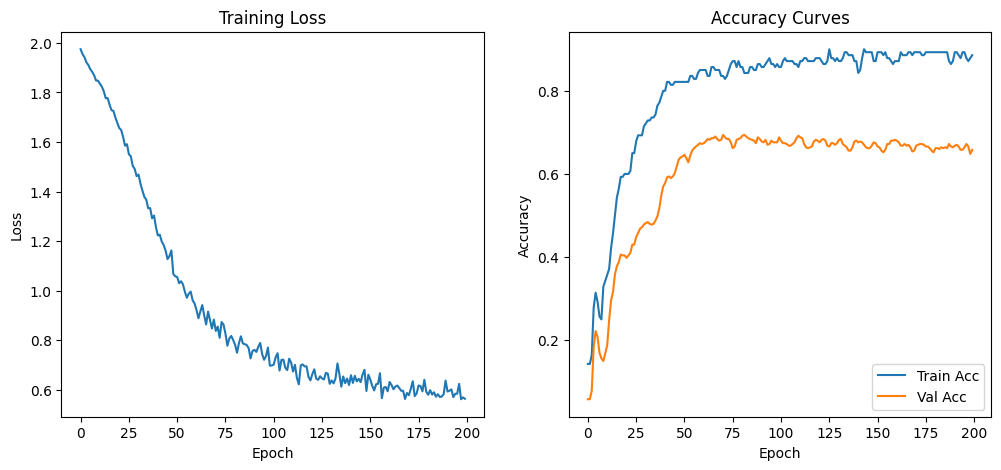

In [66]:
# =====================================
# TRAINING LOOP WITH CURVES
# =====================================

import matplotlib.pyplot as plt

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

criterion = nn.CrossEntropyLoss()

train_mask = data.train_mask
val_mask = data.val_mask
test_mask = data.test_mask

best_val_acc = 0
patience = 50
patience_counter = 0
best_model_state = None

# ---- Track Metrics ----
train_losses = []
train_accs = []
val_accs = []

for epoch in range(1, 201):

    model.train()
    optimizer.zero_grad()

    out = model(data.x, G)
    loss = criterion(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        out = model(data.x, G)
        pred = out.argmax(dim=1)

        train_acc = (pred[train_mask] == data.y[train_mask]).float().mean()
        val_acc = (pred[val_mask] == data.y[val_mask]).float().mean()
        test_acc = (pred[test_mask] == data.y[test_mask]).float().mean()

    # ---- Store metrics ----
    train_losses.append(loss.item())
    train_accs.append(train_acc.item())
    val_accs.append(val_acc.item())

    # ---- Early stopping ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | "
              f"Loss: {loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Val Acc: {val_acc:.4f} | "
              f"Test Acc: {test_acc:.4f}")

    # if patience_counter >= patience:
    #     print("Early stopping triggered.")
    #     break

# Load best model
model.load_state_dict(best_model_state)

# Final test accuracy
model.eval()
with torch.no_grad():
    out = model(data.x, G)
    pred = out.argmax(dim=1)
    final_test_acc = (pred[test_mask] == data.y[test_mask]).float().mean()

print("\nFinal Test Accuracy:", final_test_acc.item())

# =====================================
# Plot Curves
# =====================================

plt.figure(figsize=(12,5))

# Loss Curve
plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Accuracy Curve
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()
